# Homework 3
### Grupo 127
#### André Melo (ist1106937) e Gonçalo Aleixo (ist1106900)

## II. Programming and critical analysis [8v]

**Consider the parkinsons.csv dataset (available at the course’s webpage), where the goal is**
**to predict a patient’s score on the Unified Parkinson’s Disease Rating Scale based on various**
**biomedical measurements.**

**To answer question 5), average the performance of the models over 10 separate runs. In each**
**run, use a different 80-20 train-test split by setting a random_state=i, with i=1..10.**

**5. [2v] Train a Linear Regression model, an MLP Regressor with 2 hidden layers of 10**
**neurons each and no activation functions, and another MLP Regressor with 2 hidden**
**layers of 10 neurons each using ReLU activation functions. (Use random_st**

/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/

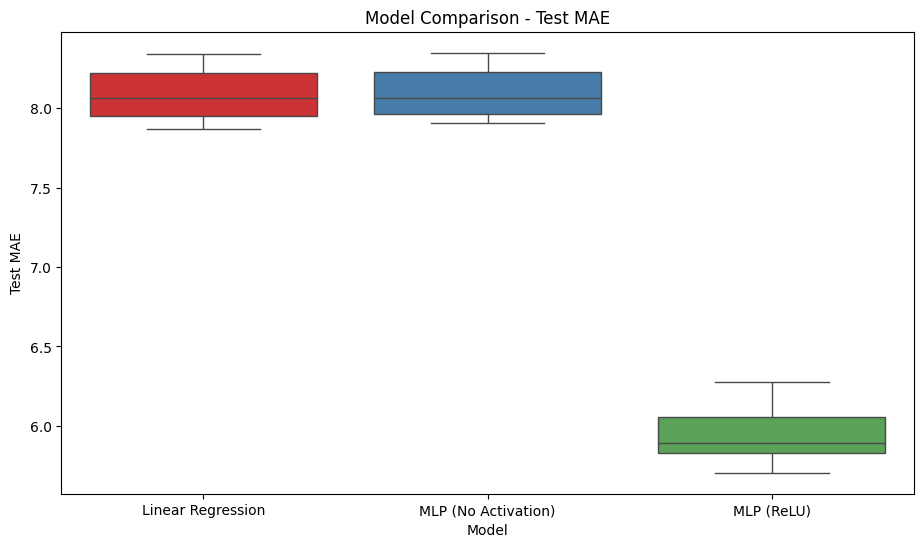

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the CSV file
df = pd.read_csv('parkinsons.csv')

#Separate features(X) from the target(Y)
X = df.drop(columns=['target'])
y = df['target']

mae_linear = []
mae_mlp_no_activation = []
mae_mlp_relu = []

#10 separate runs with different train-test splits
for i in range(1, 11):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

     # Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    mae_linear.append(mean_absolute_error(y_test, y_pred_lr))
    
    # MLP Regressor with no activation functions
    mlp_no_act = MLPRegressor(hidden_layer_sizes=(10, 10), activation='identity', random_state=0)
    mlp_no_act.fit(X_train, y_train)
    y_pred_no_act = mlp_no_act.predict(X_test)
    mae_mlp_no_activation.append(mean_absolute_error(y_test, y_pred_no_act))
    
    # MLP Regressor with ReLU activation functions
    mlp_relu = MLPRegressor(hidden_layer_sizes=(10, 10), activation='relu', random_state=0)
    mlp_relu.fit(X_train, y_train)
    y_pred_relu = mlp_relu.predict(X_test)
    mae_mlp_relu.append(mean_absolute_error(y_test, y_pred_relu))

#Boxplot of MAE for each model
mae_data = pd.DataFrame({
    'Model': ['Linear Regression'] * 10 + ['MLP (No Activation)'] * 10 + ['MLP (ReLU)'] * 10,
    'Test MAE': mae_linear + mae_mlp_no_activation + mae_mlp_relu
})

plt.figure(figsize=(11, 6)) 
sns.boxplot(x='Model', y='Test MAE', data=mae_data, palette="Set1")
plt.title('Model Comparison - Test MAE')
plt.show()

**6. [3v] Compare a Linear Regression with a MLP with no activations, and explain the impact**
**and the importance of using activation functions in a MLP. Support your reasoning with the**
**results from the boxplots.**

/var/folders/6l/xtt2r9tj2b74lzfcz2wlmqy80000gn/T/ipykernel_2257/2998946681.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Test MAE', data=mae_data, palette="Set1")


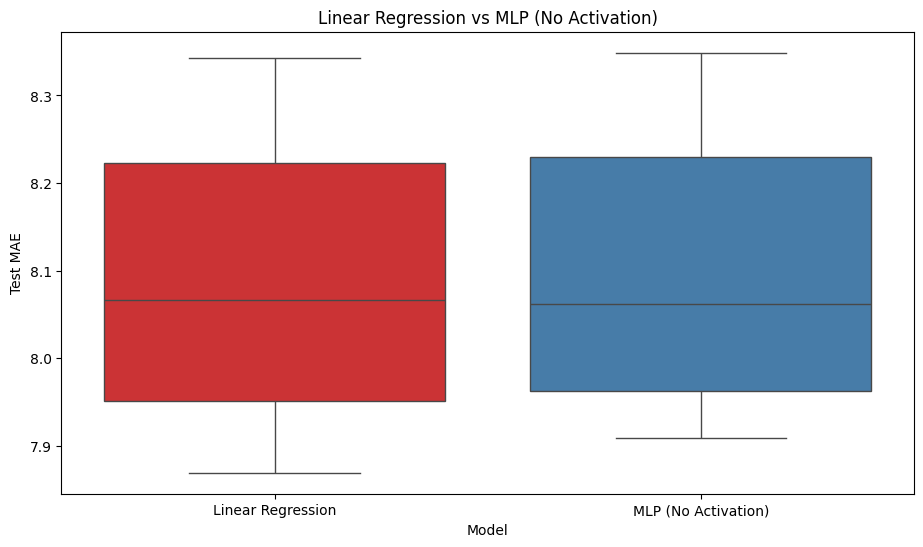

In [22]:
#Boxplot comparing Linear Regression and MLP with No Activation
mae_data = pd.DataFrame({
    'Model': ['Linear Regression'] * 10 + ['MLP (No Activation)'] * 10,
    'Test MAE': mae_linear + mae_mlp_no_activation
})

plt.figure(figsize=(11, 6))
sns.boxplot(x='Model', y='Test MAE', data=mae_data, palette="Set1")
plt.title('Linear Regression vs MLP (No Activation)')
plt.show()


Observando os diagramas em caixa, é evidente que ambos os modelos, regressão linear e MLP sem ativação, produzem distribuições muito semelhantes do Mean Absolute Error (MAE). A mediana e os intervalos interquartis do MAE para ambos os modelos são praticamente idênticos. Isto é esperado, porque a MLP sem ativação comporta-se como um modelo linear. A ausência de não linearidade significa que ela não consegue capturar padrões complexos, tornando-a equivalente a uma série de transformações lineares.

As funções de ativação no modelo MLP introduzem não linearidade numa MLP. Isto é essencial, pois os dados do mundo real muitas vezes exibem relações não lineares entre as características de entrada e a target. Sem estas funções, a MLP só consegue modelar relações lineares, o que limita a sua capacidade de generalizar ou capturar interações mais complexas nos dados.

Comparando os diagramas de caixa do modelo MLP sem ativação com o MLP com ativação ReLu, rapidamente reparamos num melhor desempenho do MLP com ativação ReLu com valores da MAE significativamente mais baixos. Demonstrando, assim, que a MLP com funções de ativação não linear consegue lidar melhor com relações mais complexas.

**7. [3v] Using a 80-20 train-test split with random_state=0, use a Grid Search to tune the**
**hyperparameters of an MLP regressor with two hidden layers (size 10 each). The**
**parameters to search over are: (i) L2 penalty, with the values {0.0001, 0.001, 0.01};**
**(ii) learning rate, with the values {0.001, 0.01, 0.1}; and (iii) batch size, with the**
**values {32, 64, 128}. Plot the test MAE for each combination of hyperparameters,**
**report the best combination, and discuss the trade-offs between the combinations**

/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/user/Library/

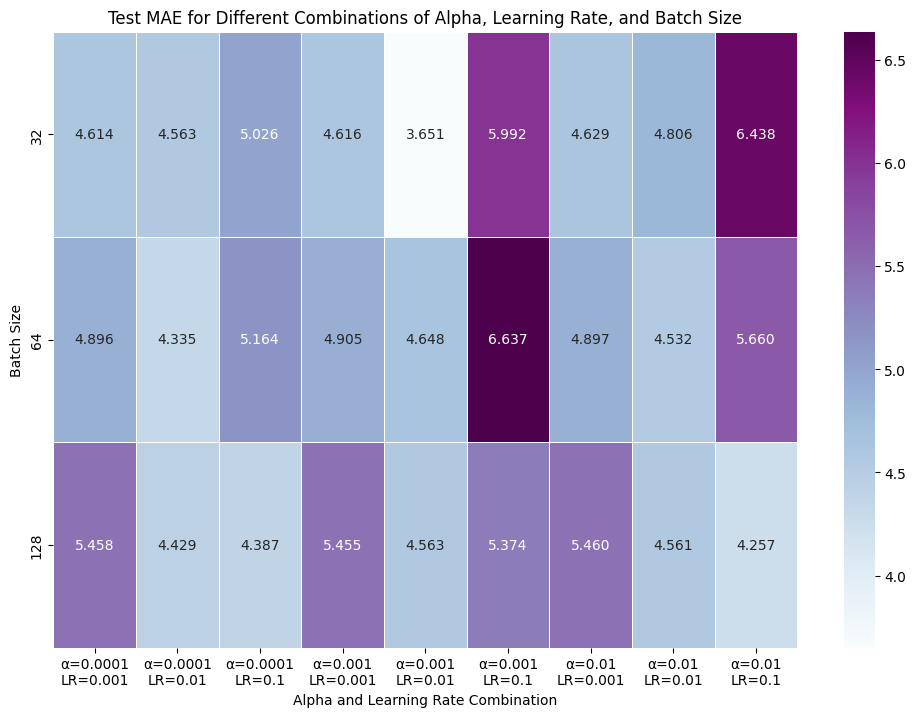

Best hyperparameter combination:
alpha             0.00100
learning_rate     0.01000
batch_size       32.00000
test_mae          3.65096
Name: 12, dtype: float64


In [33]:
#Split the data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

alphas = [0.0001, 0.001, 0.01]  #L2 penalty (alpha)
learning_rates = [0.001, 0.01, 0.1]  #Learning rate
batch_sizes = [32, 64, 128]  #Batch sizes

results = []

#All combinations of hyperparameters
for alpha in alphas:
    for lr in learning_rates:
        for batch_size in batch_sizes:
            # Define the model with the current hyperparameters
            mlp = MLPRegressor(hidden_layer_sizes=(10, 10), alpha=alpha, learning_rate_init=lr,
                               batch_size=batch_size, random_state=0)
            
            #Train the model
            mlp.fit(X_train, y_train)
            
            #Predict on the test set
            y_pred = mlp.predict(X_test)
            
            #Calculate the MAE
            test_mae = mean_absolute_error(y_test, y_pred)
            
            #Store the results
            results.append({
                'alpha': alpha,
                'learning_rate': lr,
                'batch_size': batch_size,
                'test_mae': test_mae
            })

#Heatmap
pivot_table = pd.DataFrame(results).pivot_table(index='batch_size', columns=['alpha', 'learning_rate'], values='test_mae')
pivot_table.columns = [f'α={alpha}\nLR={lr}' for alpha, lr in pivot_table.columns]

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="BuPu", linewidths=0.5)
plt.title('Test MAE for Different Combinations of Alpha, Learning Rate, and Batch Size')
plt.ylabel('Batch Size')
plt.xlabel('Alpha and Learning Rate Combination')
plt.show()

#Best hyperparameter combination
best_params = results_df.loc[results_df['test_mae'].idxmin()]
print(f"Best hyperparameter combination:\n{best_params}")

- Um alpha mais baixo proporciona mais flexibilidade ao modelo, mas corre o risco de overfitting. Um alpha mais alto penaliza pesos maiores, ajudando a prevenir o overfitting, mas pode levar a underfitting.
- Uma taxa de learning rate moderada (0.01) oferece um bom equilíbrio entre a velocidade de treino e a estabilidade da convergência, enquanto uma learning rate demasiado alta (0.1) pode impedir o modelo de convergir corretamente.
- Batch sizes mais pequenos (32) geralmente melhoram o desempenho, embora possam tornar o processo de treino mais "noisy", ou seja, resultados com maiores flutuações. Batch sizes maiores (128) tendem a suavizar o treino com resultados mais consistentes, mas podem levar a uma generalização mais fraca neste cenário.

A melhor combinação de hiperparâmetros nos teus resultados foi:
- alpha: 0.001
- learning rate: 0.01
- batch size: 32

Esta combinação obteve o MAE mais baixo (3.651), provavelmente porque equilibra uma taxa de aprendizagem moderada com a flexibilidade oferecida pela penalização L2 (alpha) e atualizações frequentes de pesos devido ao tamanho de lote mais pequeno.
